In [105]:
import json
import yfinance as yf
import logging
import datetime
from utils import ComputandoMetricas, verificando_valores_nulos, retorno_percentual_acao_individual, retorno_carteira_monetario, get_selic_multiplos_periodos,compute_metrics
from IPython.display import display, Markdown
import pandas as pd
from matplotlib import pyplot as plt
import os
plt.figure(figsize=(10, 6))

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

with open("../../data/pesos_carteira_historico.json", "r") as f:
    results_dict = json.load(f)

results_dict = dict(sorted(results_dict.items(), key=lambda x: x[0].split('_to_')[0]))  
 
valor_investido = 1000   

save_path = "../../data/"

<Figure size 1000x600 with 0 Axes>

In [112]:
if '2018-01-01_to_2020-10-01' in results_dict:
    del results_dict['2018-01-01_to_2020-10-01']
if '2018-04-01_to_2020-01-01' in results_dict:
    del results_dict['2018-04-01_to_2020-01-01']

In [115]:
logger.info("Gerando pesos marcowitz...")

pesos_carteira_marcowitz = {}

for key, value in results_dict.items(): 
    
    acoes = list(value['tickers_weights'].keys())
    
    acoes_sa = [acao if acao.endswith(".SA") else f"{acao}.SA"  for acao in acoes]
    
    data_split = key.split("_to_")
    
    start = data_split[0]
    
    end = data_split[1]
    try:
    
        comp = ComputandoMetricas(str(start), str(end), value['tickers_weights'],1000)
            
        weights_markowitz, _ = comp.computando_marcowitz()
            
        computando_marcowitz = weights_markowitz.iloc[-1].to_dict()
            
        pesos_carteira_marcowitz[f"{start}_to_{end}"] = computando_marcowitz
    except Exception as e:
        logger.error(f"Erro ao computar Markowitz para o período {start} a {end}: {e}")
        continue
    
    
logger.info("Coletando dados das ações da carteira e do markowitz para o proximo periodo")

01/21/2026 01:54:58 PM Gerando pesos marcowitz...
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  3 of 3 completed
01/21/2026 01:55:01 PM ✓ Pesos já somam 100.00% (dentro da tolerância)
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  6 of 6 completed
01/21/2026 01:55:03 PM 
1 Failed download:
01/21/2026 01:55:03 PM ['TAEE4.SA']: YFPricesMissingError('possibly delisted; no price data found  (1d 2013-07-01 -> 2015-04-01) (Yahoo error = "Data doesn\'t exist for startDate = 1372647600, endDate = 1427857200")')
01/21/2026 01:55:03 PM ⚠ Pesos ajustados: 80.00% → 100.00% (fator: 1.2500)
01/21/2026 01:55:03 PM ✓ Soma final: 100.0000%
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  6 of 6 completed
01/21/2026 01:55:05 PM ✓ Pesos já somam 100.00% (dentro da tolerância)
[**********

In [116]:
pesos_carteira_marcowitz = dict(sorted(pesos_carteira_marcowitz.items(), key=lambda x: x[0].split('_to_')[0]))

In [119]:
precos_carteira = {}

for key, value in results_dict.items():
    
    acoes = list(value['tickers_weights'].keys())
    
    acoes_sa = [acao if acao.endswith(".SA") else f"{acao}.SA"  for acao in acoes]
    
    data_split = key.split("_to_")

    start = data_split[1]
    
    data = pd.Timestamp(start)
    
    end = data + pd.DateOffset(months=3)
    
    end = end.strftime("%Y-%m-%d")
    
    date_now = datetime.datetime.now().strftime("%Y-%m-%d")
    
    if end > date_now:
        logger.info("Data final da carteira maior que a data atual, ajustando para a data atual.")
        end = date_now

    logger.info(f"Baixando dados da carteira de {start} a {end}, para as acoes {acoes_sa}")
    
    precos_carteira[f"{start}"] = yf.download(acoes_sa, start=str(start), end= str(end))["Close"]
    
    pesos = list(value['tickers_weights'].values())

01/21/2026 01:57:03 PM Baixando dados da carteira de 2015-01-01 a 2015-04-01, para as acoes ['TAEE3.SA', 'WEGE3.SA', 'YDUQ3.SA']
[*********************100%***********************]  3 of 3 completed
01/21/2026 01:57:04 PM Baixando dados da carteira de 2015-04-01 a 2015-07-01, para as acoes ['AZZA3.SA', 'CGRA4.SA', 'MULT3.SA', 'RADL3.SA', 'TAEE4.SA', 'WEGE3.SA']
[*********************100%***********************]  6 of 6 completed
01/21/2026 01:57:06 PM 
1 Failed download:
01/21/2026 01:57:06 PM ['TAEE4.SA']: YFPricesMissingError('possibly delisted; no price data found  (1d 2015-04-01 -> 2015-07-01) (Yahoo error = "Data doesn\'t exist for startDate = 1427857200, endDate = 1435719600")')
01/21/2026 01:57:06 PM Baixando dados da carteira de 2015-07-01 a 2015-10-01, para as acoes ['AFLT3.SA', 'CGRA4.SA', 'MULT3.SA', 'QUAL3.SA', 'SMTO3.SA', 'WIZC3.SA']
[*********************100%***********************]  6 of 6 completed
01/21/2026 01:57:07 PM Baixando dados da carteira de 2015-10-01 a 2016-01

In [121]:
precos_carteira = dict(sorted(precos_carteira.items(), key=lambda x: x[0]))

In [122]:
precos_carteira_marcowitz = {}

for key, value in pesos_carteira_marcowitz.items():
    
    acoes = list(value.keys())
    
    acoes_sa = [acao if acao.endswith(".SA") else f"{acao}.SA"  for acao in acoes]
    
    data_split = key.split("_to_")

    start = data_split[1]
    
    data = pd.Timestamp(start)
    
    end = data + pd.DateOffset(months=3)
    
    end = end.strftime("%Y-%m-%d")
    
    date_now = datetime.datetime.now().strftime("%Y-%m-%d")
    
    if end > date_now:
        logger.info("Data final da carteira maior que a data atual, ajustando para a data atual.")
        end = date_now
        
    logger.info(f"Baixando dados de marcowitz {start} a {end}, para as acoes {acoes_sa}")
    
    precos_carteira_marcowitz[f'{start}'] = yf.download(acoes_sa, start=str(start), end= str(end))["Close"]

01/21/2026 01:58:11 PM Baixando dados de marcowitz 2015-01-01 a 2015-04-01, para as acoes ['TAEE3.SA', 'WEGE3.SA', 'YDUQ3.SA']
[*********************100%***********************]  3 of 3 completed
01/21/2026 01:58:12 PM Baixando dados de marcowitz 2015-04-01 a 2015-07-01, para as acoes ['AZZA3.SA', 'CGRA4.SA', 'MULT3.SA', 'RADL3.SA', 'WEGE3.SA']
[*********************100%***********************]  5 of 5 completed
01/21/2026 01:58:13 PM Baixando dados de marcowitz 2015-07-01 a 2015-10-01, para as acoes ['AFLT3.SA', 'CGRA4.SA', 'MULT3.SA', 'QUAL3.SA', 'SMTO3.SA', 'WIZC3.SA']
[*********************100%***********************]  6 of 6 completed
01/21/2026 01:58:14 PM Baixando dados de marcowitz 2015-10-01 a 2016-01-01, para as acoes ['CSUD3.SA', 'LREN3.SA', 'QUAL3.SA', 'TAEE11.SA', 'TAEE3.SA', 'TOTS3.SA', 'WEGE3.SA']
[*********************100%***********************]  7 of 7 completed
01/21/2026 01:58:15 PM Baixando dados de marcowitz 2016-01-01 a 2016-04-01, para as acoes ['ABEV3.SA', 'COG

In [123]:
carteira = pd.DataFrame()
carteira_marcowitz = pd.DataFrame()

interacoes = 0

for key, value in results_dict.items():
    data_split = key.split("_to_")
    start = data_split[0]
    end = data_split[1]
    print("*" * 40)
    display(Markdown(f"**O retorno da carteira para o período: {key}**"))
    
    pesos_carteira = value['tickers_weights']
    
    precos_carteira_selecionada = precos_carteira[end]
    
    pesos_sem_erro = verificando_valores_nulos(pesos_carteira, precos_carteira_selecionada)
    
    precos_sem_nan = precos_carteira[end].dropna(axis=1)
    
    carteira_percentual_acoes = retorno_percentual_acao_individual(pesos_sem_erro, precos_sem_nan)
    
    try:
        pesos_carteira_marcowitz_selecionada = pesos_carteira_marcowitz[key]
        precos_carteira_marcowitz_selecionada = precos_carteira_marcowitz[end]
        pesos_sem_erro_markowitz = verificando_valores_nulos(pesos_carteira_marcowitz_selecionada, precos_carteira_marcowitz_selecionada)
        pesos_sem_erro_markowitz = {key_: value*100 for key_, value in pesos_sem_erro_markowitz.items()}
    
        precos_sem_nan_markwitz = precos_carteira_marcowitz[end].dropna(axis=1)
    
        carteira_percentual_acoes_marcowitz = retorno_percentual_acao_individual(pesos_sem_erro_markowitz, precos_sem_nan_markwitz)
    except Exception as e:  
        logger.info(f"Erro ao obter:{e}")
    
    data = pd.DataFrame(pesos_sem_erro, index=["Pesos"]).T
    data_markwitz = pd.DataFrame(pesos_sem_erro_markowitz, index=["Pesos"]).T
    
    if not carteira_percentual_acoes.empty:
        data['retornos em %'] = pd.DataFrame(carteira_percentual_acoes)
        data_markwitz['retornos markwitz em %'] = pd.DataFrame(carteira_percentual_acoes_marcowitz)
    else:
        print("Nenhum dado foi obtido!")
        
    display(data.T.style.set_caption("Pesos").background_gradient(cmap="Blues"))
    
    display(data_markwitz.T.style.set_caption("Pesos").background_gradient(cmap="Blues"))
    
    data.to_csv(f"{save_path}/historico_carteira/pesos_{key}_carteira.csv")
    
    data_markwitz.to_csv(f"{save_path}/historico_carteira_markowitz/pesos_{key}_carteira_markowitz.csv")
    
    if interacoes == 0:
        valor_carteira = retorno_carteira_monetario(precos_sem_nan, pesos_sem_erro.values(), valor_investido)
        
        valor_carteira_markwitz = retorno_carteira_monetario(precos_sem_nan_markwitz, pesos_sem_erro_markowitz.values(), valor_investido)

        
    else:   
        valor_carteira = retorno_carteira_monetario(precos_sem_nan, pesos_sem_erro.values(), valor_atual_carteira)
        
        valor_carteira_markwitz = retorno_carteira_monetario(precos_sem_nan_markwitz, pesos_sem_erro_markowitz.values(), valor_atual_carteira_markwitz)
    
    carteira = pd.concat([carteira, valor_carteira])
    carteira_marcowitz = pd.concat([carteira_marcowitz, valor_carteira_markwitz])
    
    try:
        valor_atual_carteira = int(valor_carteira.iloc[-1])
        valor_atual_carteira_markwitz = int(valor_carteira_markwitz.iloc[-1])
    
    except:
        pass
    
    interacoes = interacoes + 1

****************************************


**O retorno da carteira para o período: 2013-04-01_to_2015-01-01**

,TAEE3.SA,WEGE3.SA,YDUQ3.SA
Pesos,35.000000,35.000000,30.000000
retornos em %,0.000000,3.488136,-10.612624


,TAEE3.SA,WEGE3.SA,YDUQ3.SA
Pesos,30.691597,47.699019,21.609384
retornos markwitz em %,0.000000,3.488074,-10.612645


****************************************


...

,BLAU3.SA,ENGI3.SA,ITUB4.SA,TRIS3.SA,WEGE3.SA
Pesos,6.545527,15.942875,42.063405,0.000000,35.448193
retornos markwitz em %,10.499154,3.058010,12.720893,nan,39.093681


****************************************


**O retorno da carteira para o período: 2024-04-01_to_2026-01-01**

,BLAU3.SA,CGRA4.SA,ALOS3.SA,BPAC11.SA,CYRE3.SA,ITSA4.SA,LREN3.SA
Pesos,20.000000,20.000000,15.000000,15.000000,10.000000,10.000000,10.000000
retornos em %,-21.590121,-4.447689,-0.488825,2.798508,0.356154,1.679260,4.930665


,ALOS3.SA,BLAU3.SA,BPAC11.SA,CGRA4.SA,CYRE3.SA,ITSA4.SA,LREN3.SA
Pesos,27.051092,0.000000,0.000000,25.146548,0.000000,43.136370,4.665989
retornos markwitz em %,-0.488825,-21.590121,2.798508,-4.447689,nan,1.679260,4.930665


Buscando dados de 2015-01-01 até 2020-01-01...
  ✓ 1253 registros obtidos
Buscando dados de 2020-01-02 até 2025-01-02...
  ✓ 1256 registros obtidos
Buscando dados de 2025-01-03 até 2026-01-01...


[*********************100%***********************]  1 of 1 completed
01/21/2026 02:15:04 PM ✅ Métricas salvas em: ../../data/metricas_carteiras_historico.csv


  ✓ 251 registros obtidos

✓ Total de registros: 2760
✓ Período: 2015-01-02 até 2025-12-31


01/21/2026 02:15:04 PM ✅ Gráfico salvo em: ../../image\grafico_retornos_carteira_historico.png
01/21/2026 02:15:04 PM Avaliação concluida com sucesso!


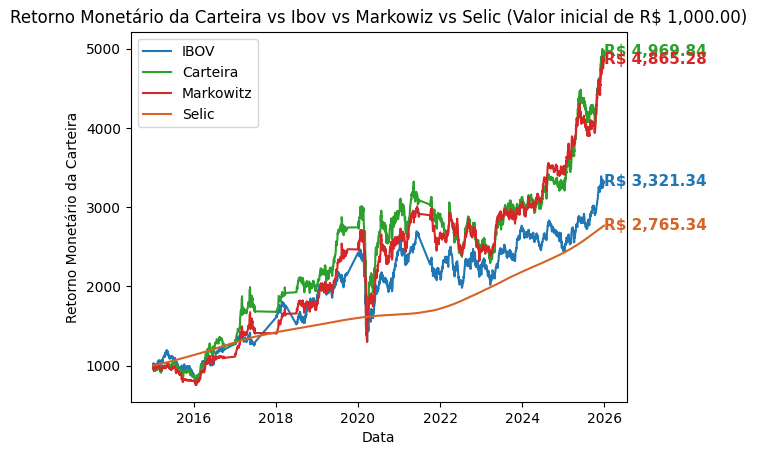

In [126]:
#datas_lista = list(results_dict.keys())
datas_lista = list(precos_carteira.keys())

start_bove = datas_lista[0]

end_bove = datas_lista[-1]

selic = get_selic_multiplos_periodos(start_bove, end_bove)

selic_acumulada =  ((selic/100 + 1).cumprod())*valor_investido


ibov = yf.download("^BVSP", start=start_bove, end=end_bove)["Close"]

ibov_retornos = (ibov.pct_change()+1).cumprod()*valor_investido

retorno_acumulado_monetario = pd.concat([selic_acumulada, ibov_retornos], axis=1).rename(columns={"selic": "Selic", "^BVSP": "IBOV"})

carteira_marcowitz = carteira_marcowitz[~carteira_marcowitz.index.duplicated(keep='last')]

carteira = carteira[~carteira.index.duplicated(keep='last')]

retorno_acumulado_monetario['Markowitz'] = carteira_marcowitz

retorno_acumulado_monetario['Carteira'] = carteira

metricas_carteiras = compute_metrics(retorno_acumulado_monetario)

metricas_carteiras.style.set_caption("Métricas das Carteiras").background_gradient(cmap="Blues")


cores = {'IBOV': '#1f77b4', 'Carteira': '#2ca02c', 'Markowitz': '#d62728', 'Selic': "#d66427"}

retorno_acumulado_monetario = retorno_acumulado_monetario.dropna()

for nome in ['IBOV', 
             'Carteira', 
             'Markowitz', 
             'Selic']:
    plt.plot(
            retorno_acumulado_monetario.index,
            retorno_acumulado_monetario[nome],
                label=nome,
                color=cores[nome]
            )
    ultimo_x = retorno_acumulado_monetario[nome].index[-1]
    ultimo_y = retorno_acumulado_monetario[nome].iloc[-1]
    plt.text(
                ultimo_x, ultimo_y,
                f'R$ {ultimo_y:,.2f}',
                color=cores[nome],
                fontsize=11,
                va='center',
                fontweight='bold'
            )

plt.legend()
plt.xlabel("Data")
plt.ylabel("Retorno Monetário da Carteira")
plt.title(f"Retorno Monetário da Carteira vs Ibov vs Markowiz vs Selic (Valor inicial de R$ {valor_investido:,.2f})")

os.makedirs(save_path, exist_ok=True)

metrics_file = os.path.join(save_path, "metricas_carteiras_historico.csv")

metricas_carteiras.to_csv(metrics_file)

logger.info(f"✅ Métricas salvas em: {metrics_file}")

image_path = "../../image"

grafico_file = os.path.join(image_path, f"grafico_retornos_carteira_historico.png")

plt.savefig(grafico_file, dpi=300, bbox_inches='tight')

logger.info(f"✅ Gráfico salvo em: {grafico_file}")

logger.info(f"Avaliação concluida com sucesso!")

In [125]:
metrics_file

'../../data/metricas_carteiras_historico.csv'